In [1]:
!pip install -q fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.1 MB/s eta 0:00:00:00:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Выгрузка данных

In [3]:
# данные о реальном спросе
real_demand = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/real_demand_data.parquet', engine='fastparquet')

# данные о стоках
stock = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/stock_data.parquet', engine='fastparquet')

# данные о продажах (реальность)
gmv = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/gmv_dataset.parquet', engine='fastparquet')

### Функция определяющая тип ряда

статья - https://help.theowlsolutions.com/supply-chain-academy/6486Sa6uL3imxMG13tNmTp/demand-patterns/66NSQAyzqzPoodhh5pWWYm

In [4]:
def classify_demand_pattern(ts, adi_threshold=1.32, cv2_threshold=0.49):
    """
    Классифицирует тип спроса по методологии Syntetos/Boylan.

    Параметры:
    ----------
    ts : array-like
        Временной ряд (список или массив чисел).
    adi_threshold : float, default=1.32
        Порог ADI для разделения частого/редкого спроса.
    cv2_threshold : float, default=0.49
        Порог CV² для разделения стабильного/нестабильного объёма.

    Возвращает:
    -------
    str
        Один из пяти типов:
        - 'retired'     : все значения ряда нулевые или ряд пуст
        - 'smooth'      : гладкий (частый, стабильный объём)
        - 'erratic'     : нестабильный (частый, нестабильный объём)
        - 'intermittent': прерывистый (редкий, стабильный объём)
        - 'lumpy'       : комковатый (редкий, нестабильный объём)
    """
    # Преобразуем в numpy-массив для удобства
    ts = np.asarray(ts)
    
    # Проверка на retired: пустой ряд или все значения равны нулю
    if ts.size == 0 or np.all(ts == 0):
        return 'retired'
    
    # Рассчитываем общую длину ряда
    T = len(ts)
    
    # Выделяем ненулевые значения
    non_zero = ts[ts != 0]
    N = len(non_zero)
    
    # 1. Расчёт ADI (Average Demand Interval = общее кол-во элементов ряда / кол-во ненулевых элементов ряда)
    ADI = T / N
    
    # 2. Расчёт CV² (Coefficient of Variation squared) для ненулевых значений
    if N <= 1:
        CV2 = 0.0  # Вариация отсутствует
    else:
        mean_demand = np.mean(non_zero)
        std_demand = np.std(non_zero, ddof=1)
        if mean_demand == 0:
            CV2 = 0.0
        else:
            CV2 = (std_demand / mean_demand) ** 2
    
    is_high_adi = ADI >= adi_threshold
    is_high_cv2 = CV2 >= cv2_threshold
    
    if not is_high_adi and not is_high_cv2:
        return 'smooth'
    elif not is_high_adi and is_high_cv2:
        return 'erratic'
    elif is_high_adi and not is_high_cv2:
        return 'intermittent'
    else:
        return 'lumpy'

### Определяем тип ряда (intermittent / not_intermittent / retired)

In [5]:
sku_list = list(set(real_demand['SKU_id']))
real_demand = real_demand.sort_values("date")

ts_dict = {}

for i in sku_list:

    # Фильтруемся по текущей SKU, забираем список последовательных значений спроса данной SKU
    demand_list = list(real_demand.query("SKU_id == @i")['real_demand'])

    # оставляем последние 90 (или меньше) дней наблюдений
    # логика - есть случаи, когда SKU долгое время продавалась плохо и медленно на старте (много нулевых значений), а потом разгонялась
    # такие ряды не intermittent, это просто новинки, которые на старте набирали популярность / отзывы
    demand_list = demand_list[-90:] 


    # Определяем тип ряда для каждой SKU
    ts_dict[i] = classify_demand_pattern(demand_list)

In [6]:
pd.set_option('display.float_format', '{:,.2f}'.format)

ts_dict_df = pd.DataFrame(ts_dict.values(), ts_dict.keys()).reset_index()
ts_dict_df = ts_dict_df.rename(columns = {'index': 'SKU_id', 0: 'ts_type'})

sku_gmv_df = real_demand.groupby(['SKU_id']).agg({'real_demand': 'sum'}).reset_index()

result = pd.merge(ts_dict_df, sku_gmv_df, how = 'left', on = 'SKU_id')

summary = result.groupby(['ts_type']).agg({'SKU_id':'count', 'real_demand': 'sum'}).reset_index()
total_gmv = summary['real_demand'].sum()

summary['share_%'] = (summary['real_demand'] / total_gmv * 100).round(2)

summary

,ts_type,SKU_id,real_demand,share_%
0,erratic,835,"2,180,615.00",19.69
1,intermittent,8348,"1,537,318.00",13.88
2,lumpy,3170,"1,085,711.00",9.80
3,retired,1307,"149,525.00",1.35
4,smooth,1811,"6,123,346.00",55.28


In [36]:
ts_dict_df.to_csv('ts_dict_df')

In [24]:
result.query(" ts_type == 'erratic' ").sort_values("real_demand").tail(50)

,SKU_id,ts_type,real_demand
12346,726230922,erratic,"7,397.00"
6118,503198616,erratic,"7,521.00"
5009,1108584857,erratic,"7,587.00"
14630,944142683,erratic,"7,678.00"
5999,427766396,erratic,"7,727.00"
6379,1047279093,erratic,"7,790.00"
14881,862223119,erratic,"7,925.00"
791,258934392,erratic,"8,818.00"
27,215482427,erratic,"9,068.00"
12655,703162986,erratic,"9,249.00"


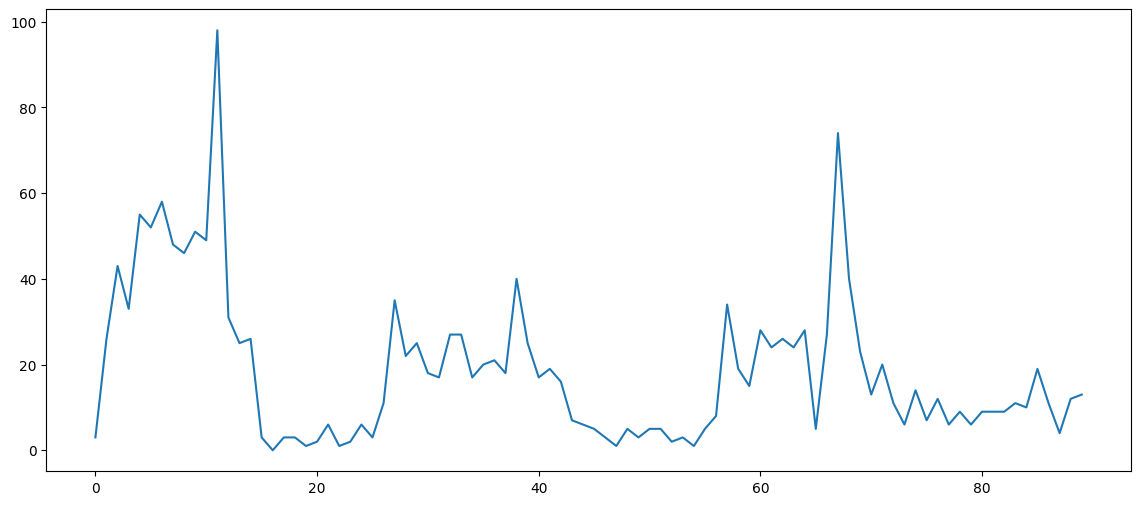

In [33]:
i = 416123127		

demand_list = list(real_demand.query("SKU_id == @i")['real_demand'])
demand_list = demand_list
demand_list = demand_list[-90:] 

plt.figure(figsize=(14, 6))
plt.plot(demand_list)

In [29]:
real_demand.query(" SKU_id == 526121643 ").tail(50)

,date,SKU_id,real_demand
4775582,2025-08-12,526121643,3.00
4783930,2025-08-13,526121643,1.00
4795728,2025-08-14,526121643,3.00
4804178,2025-08-15,526121643,1.00
4816557,2025-08-16,526121643,5.00
4818629,2025-08-17,526121643,0.00
4834191,2025-08-18,526121643,1.00
4844296,2025-08-19,526121643,1.00
4848687,2025-08-20,526121643,0.00
4858732,2025-08-21,526121643,0.00


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(demand_list)

In [30]:
gmv.query(" SKU_id == 526121643 ").sort_values('Date').tail(50)

,YYYYMM,Date,Category3,Category4,Brand,SupplierID,SellerID,SKU_id,is_promo,stock_qty,GMV_wo_VAT,GMV_wo_VAT_Acc,Items_Acc
6311761,202508,2025-08-12,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,457,0.00,"2,035.83",3
6311762,202508,2025-08-13,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,455,"1,078.33",644.17,1
6311763,202508,2025-08-14,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,450,"1,984.17","2,165.00",3
6311764,202508,2025-08-15,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,445,"2,040.83",693.33,1
6311765,202508,2025-08-16,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,448,698.33,"3,374.17",5
6311766,202508,2025-08-17,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,449,693.33,0.00,0
6311767,202508,2025-08-18,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,449,0.00,692.50,1
6311768,202508,2025-08-19,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,445,"2,814.17",693.33,1
6311769,202508,2025-08-20,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,439,698.33,0.00,0
6311770,202508,2025-08-21,Масла автомобильные,Автохимия - Масло моторное,PATRIOT,11017561344610,32323,526121643,False,437,640.00,0.00,0


In [23]:
stock.query(" SKU_id == 836433338 ").tail(50)

,DATE,SKU_id,stock_qty
7863424,2025-08-12,836433338,177
7877114,2025-08-13,836433338,184
7890787,2025-08-14,836433338,165
7904376,2025-08-15,836433338,125
7917874,2025-08-16,836433338,118
7931337,2025-08-17,836433338,122
7944777,2025-08-18,836433338,88
7958268,2025-08-19,836433338,64
7971969,2025-08-20,836433338,57
7985531,2025-08-21,836433338,17


In [ ]:
real_demand

In [ ]:
sku_list